In [ ]:
!pip install nltools
!pip install nilearn
!pip install nibabel

In [ ]:
%pylab inline
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
from scipy.io import loadmat
import nilearn as nl             # pip: nilearn==0.10.0
import nibabel as nib
import nltools as nlt
from matplotlib.colors import ListedColormap



Populating the interactive namespace from numpy and matplotlib


In [ ]:
from sklearn.manifold import LocallyLinearEmbedding
import scipy
import numpy as np


################################################################################
# Archetypal Analysis        ####################################################
################################################################################
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class ArchetypalAnalysis(BaseEstimator, TransformerMixin):

    def __init__(self, n_archetypes=None, tmax=20, iterations=10):
        '''
        Implements archetypal analysis
            Archetypal Analysis as an Autoencoder (Bauckhage et al. 2015)

        Parameters
        ----------

        n_archetypes : the number of archetype

        tmax : the number of iterations of the derivative update

        iterations : the number of iterations of the overall algorithm


        Notes
        ---------

        The matrices have the following dimensions (following the above paper)
        [X] - m x n
        [Z] - m x k
        [B] - n x k
        [A] - k x n
        [e_A] - k x 1
        [e_B] - n x 1

        Source: https://miller-blog.com/archetypal-analysis/

        '''
        self.n_archetypes = n_archetypes
        self.tmax = tmax
        self.iterations = iterations

        N = self.n_archetypes
        x, y = np.zeros(N), np.zeros(N)
        x[1:] = np.cumsum(np.cos(np.arange(0, N - 1) * 2 * np.pi / N))
        y[1:] = np.cumsum(np.sin(np.arange(0, N - 1) * 2 * np.pi / N))
        self.map2D = np.vstack((x, y))

    def fit(self, X, y=None):
        """Fit the model with X using Archetypal Analysis
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : Ignored
        Returns
        -------
        self : object
            Returns the instance itself.

        Source: https://miller-blog.com/archetypal-analysis/
        """
        self._fit(X)
        return self

    def _fit(self, X):
        k = self.n_archetypes
        m, n = X.shape

        B = np.eye(n, k)
        Z = X @ B

        for i in range(self.iterations):
            A = self._computeA(X, Z, self.tmax)
            B = self._computeB(X, A, self.tmax)
            Z = X @ B
            print('RSS = {}'.format(self._rss(X, A, Z)))

        self.Z_ = Z
        self.A_ = A

    def _computeA(self, X, Z, tmax):
        '''
        Algorithm 1 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        m, n = X.shape
        k = self.n_archetypes

        A = np.zeros((k, n))
        A[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            # [G] ~  k x n
            G = 2.0 * ((Z.T @ Z) @ A - Z.T @ X)
            # Get the argument mins along each column
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(n)] = 1.0
            A += 2.0 / (t + 2.0) * (e - A)
        return A

    def _computeB(self, X, A, tmax):
        '''
        Algorithm 2 of Bauckhage et al. 2015
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        k, n = A.shape
        B = np.zeros((n, k))
        B[0, :] = 1.0
        for t in range(tmax):
            # brackets are important to get reasonable sizes
            t1 = X.T @ (X @ B) @ (A @ A.T)
            t2 = X.T @ (X @ A.T)
            G = 2.0 * (t1 - t2)
            argmins = np.argmin(G, axis=0)
            e = np.zeros(G.shape)
            e[argmins, range(k)] = 1.0
            B += 2.0 / (t + 2.0) * (e - B)
        return B

    def archetypes(self):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self.Z_

    def transform(self, X):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return self._computeA(X, self.Z_, self.tmax)

    def _rss(self, X, A, Z):
        '''
        Source: https://miller-blog.com/archetypal-analysis/
        '''
        return np.linalg.norm(X - Z @ A)


def archetypal_plot(ax, data, dp, epsilon=0.2):
    '''
    Source: Dr. Luke Bovard
    '''
    ax.scatter(data[0, :], data[1, :], alpha=0.6, linewidths=10)
    ax.scatter(dp[0, :], dp[1, :], c='orange')

    for i in range(dp.shape[1]):
        if dp[0, i] < 0.5:
            eps_x = -epsilon
        else:
            eps_x = epsilon
        if dp[1, i] < np.max(dp[1, :]) / 2.0:
            eps_y = -epsilon
        else:
            eps_y = epsilon
        ax.text(dp[0, i] + eps_x, dp[1, i] + eps_y, "{}".format(i + 1))
    return ax

In [ ]:
pieman_name = 'pieman_data.mat'
pieman_data = loadmat(pieman_name)
pieman_conds = ['intact', 'paragraph', 'word', 'rest']

In [ ]:
posterior = loadmat('pieman_posterior_K700.mat')
centers = posterior['posterior']['centers'][0][0][0][0][0]
widths = np.array(list(posterior['posterior']['widths'][0][0][0][0][0][:, 0].T))

In [ ]:
data = []
conds = []
for c in pieman_conds:
    if c == 'paragraph':
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.where(np.arange(pieman_data[c].shape[1]) != 3)[0]))
    else:
        next_data = list(map(lambda i: pieman_data[c][:, i][0], np.arange(pieman_data[c].shape[1])))
    data.extend(next_data)
    conds.extend([c]*len(next_data))


In [ ]:
conds_array = np.array(conds)

In [ ]:
intact_list = [data[i] for i in np.where(conds_array=='intact')[0]]

In [ ]:
intact_array = np.array(intact_list)

In [ ]:
archs = ArchetypalAnalysis(n_archetypes=5,iterations=10,tmax=300)


In [ ]:
archs.fit(intact_array[0])

Z=(archs.archetypes())

RSS = 469.870802912148
RSS = 451.860174620089
RSS = 448.311991800234
RSS = 446.708491986472
RSS = 445.99106079051523
RSS = 445.68800699084125
RSS = 445.5330436393097
RSS = 445.43158774574977
RSS = 445.3532796461606
RSS = 445.2908001648331


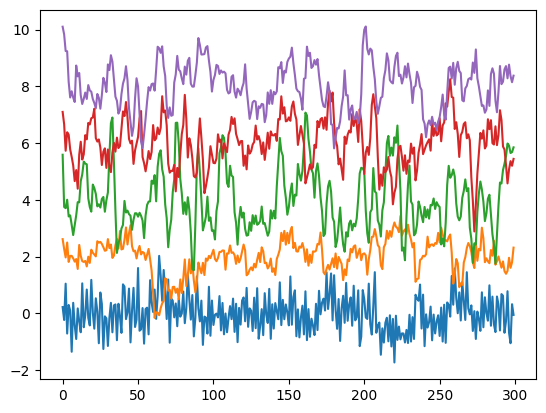

In [ ]:
for i in np.arange(5):
  plt.plot(Z[:, i]+ 2*i)


In [ ]:
locs_arch_1 = archs.A_[0]>.9

In [ ]:
key = os.path.join('Schaefer2018_1000Parcels_7Networks_order.txt')
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'Vis': 'Visual',
    'SomMot': 'Somatomotor',
    'DorsAttn': 'Dorsal attention',
    'SalVentAttn': 'Ventral attention',
    'Limbic': 'Limbic',
    'Cont': 'Frontoparietal',
    'Default': 'Default mode'
}

network_colors = {
    'Visual': '#D7DF23',
    'Somatomotor': '#39B54A',
    'Dorsal attention': '#00A79D',
    'Ventral attention': '#27AAE1',
    'Limbic': '#1C75BC',
    'Frontoparietal': '#92278F',
    'Default mode': '#EE2A7B'
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key           # pip: nibabel==5.0.1

,x,y,z,study,hemisphere,network,code
id,,,,,,,
1,120.0,14.0,127.0,7Networks,L,Visual,1.0
2,120.0,14.0,128.0,7Networks,L,Visual,1.0
3,120.0,14.0,129.0,7Networks,L,Visual,1.0
4,120.0,14.0,130.0,7Networks,L,Visual,1.0
5,120.0,14.0,131.0,7Networks,L,Visual,1.0
...,...,...,...,...,...,...,...
997,208.0,65.0,82.0,7Networks,R,Default mode,7.0
998,208.0,65.0,83.0,7Networks,R,Default mode,7.0
999,235.0,149.0,37.0,7Networks,R,Frontoparietal,6.0


In [ ]:
nii_fname = os.path.join('Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz')


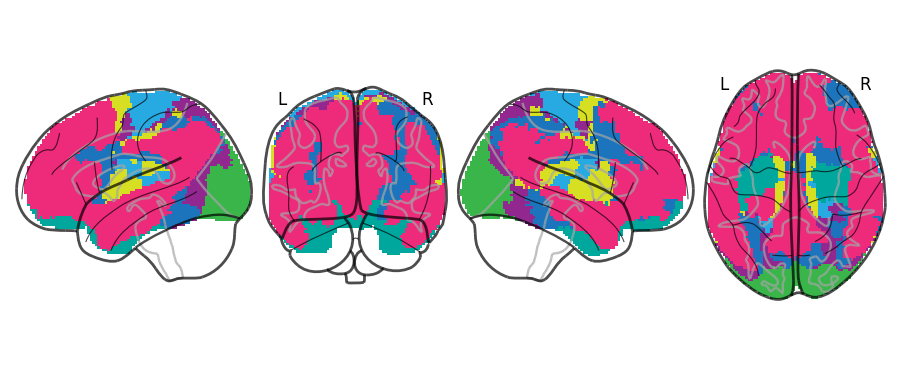

In [ ]:
nx = nlt.Brain_Data(nii_fname)
nx.data = np.array([key.loc[i, 'code'] for i in nx.data]).astype(float)
networks = nx.to_nifti()

fname = os.path.join('networks.pdf')
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz', output_file=fname)

# also display figure here
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz')

In [ ]:

import warnings
from nilearn.maskers import NiftiMasker


def nii2cmu(nifti_file, mask_file=None):
    '''
    inputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename of a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output.  If ignored or set to None, no voxels will
                 be masked out.

    outputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.
    '''
    def fullfact(dims):
        '''
        Replicates MATLAB's fullfact function (behaves the same way)
        '''
        vals = np.asmatrix(range(1, dims[0] + 1)).T
        if len(dims) == 1:
            return vals
        else:
            aftervals = np.asmatrix(fullfact(dims[1:]))
            inds = np.asmatrix(np.zeros((np.prod(dims), len(dims))))
            row = 0
            for i in range(aftervals.shape[0]):
                inds[row:(row + len(vals)), 0] = vals
                inds[row:(row + len(vals)), 1:] = np.tile(aftervals[i, :], (len(vals), 1))
                row += len(vals)
            return inds

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        if type(nifti_file) == str:
            img = nib.load(nifti_file)
        elif type(nifti_file) == nib.nifti1.Nifti1Image:
            img = nifti_file
        else:
            raise ValueError('nifti_file must be a filename or nibabel Nifti1Image object')

        mask = NiftiMasker(mask_strategy='background')
        if mask_file is None:
            mask.fit(nifti_file)
        else:
            mask.fit(mask_file)

    hdr = img.header
    S = img.get_sform()
    vox_size = hdr.get_zooms()
    im_size = img.shape

    if len(img.shape) > 3:
        N = img.shape[3]
    else:
        N = 1

    Y = np.float32(mask.transform(nifti_file)).copy()
    vmask = np.nonzero(np.array(np.reshape(mask.mask_img_.dataobj, (1, np.prod(mask.mask_img_.shape)), order='C')))[1]
    vox_coords = fullfact(img.shape[0:3])[vmask, ::-1]-1

    R = np.array(np.dot(vox_coords, S[0:3, 0:3])) + S[:3, 3]

    return {'Y': Y, 'R': R}

def cmu2nii(Y, R, template=None):
    '''
    inputs:
      Y: a number-of-timepoints by number-of-voxels numpy array containing the
         image data.  Each row of Y is an fMRI volume in the original nifti
         file.

      R: a number-of-voxels by 3 numpy array containing the voxel locations.
         Row indices of R match the column indices in Y.

      template: a filename of a .nii or .nii.gz file to be used as an image
                template.  Header information of the outputted nifti images will
                be read from the header file.  If this argument is ignored or
                set to None, header information will be inferred based on the
                R array.

    outputs:
      nifti_file: a filename of a .nii or .nii.gz file to be converted into
                  CMU format

      mask_file: a filename for a .nii or .nii.gz file to be used as a mask; all
                 zero-valued voxels in the mask will be ignored in the CMU-
                 formatted output

    outputs:
      img: a nibabel Nifti1Image object containing the fMRI data
    '''
    Y = np.array(Y, ndmin=2)
    img = nib.load(template)
    S = img.affine
    locs = np.array(np.dot(R - S[:3, 3], np.linalg.inv(S[0:3, 0:3])), dtype='int')

    data = np.zeros(tuple(list(img.shape)[0:3]+[Y.shape[0]]))

    # loop over data and locations to fill in activations
    for i in range(Y.shape[0]):
        for j in range(R.shape[0]):
            data[locs[j, 0], locs[j, 1], locs[j, 2], i] = Y[i, j]

    return nib.Nifti1Image(data, affine=img.affine)



In [ ]:
# load network parcellations in CMU format
networks_cmu = nii2cmu(nii_fname)

# covert voxel values in the reference image to network codes
networks_cmu['Y'] = np.atleast_2d(np.array([key.loc[i, 'code'] for i in networks_cmu['Y']]).astype(float))

In [ ]:
def node_labels(centers, widths, networks_cmu):
    labels = []
    for c, w in zip(centers, widths):
        r = rbf(networks_cmu['R'], c, w)

        label_weights = [sum(r[networks_cmu['Y'].ravel() == i]) for i in range(1, len(network_codes) + 1)]
        labels.append(np.argmax(label_weights) + 1)

    return pd.DataFrame({'code': labels, 'Network': [list(lookup_table.values())[i - 1] for i in labels]})

In [ ]:
def rbf(R, center, width):
    return np.exp(-np.sum((R - center) ** 2, axis=1) / width)

In [ ]:
node_codes = node_labels(centers, widths, networks_cmu)
node_codes

,code,Network
0,4,Ventral attention
1,3,Dorsal attention
2,1,Visual
3,6,Frontoparietal
4,4,Ventral attention
...,...,...
695,2,Somatomotor
696,4,Ventral attention
697,4,Ventral attention
698,4,Ventral attention


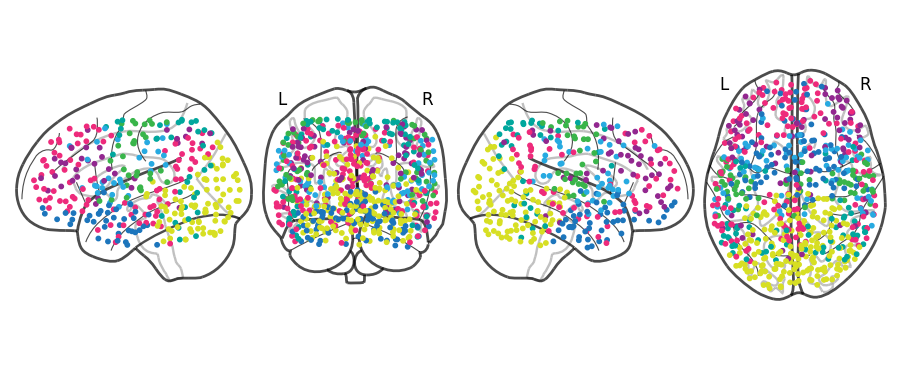

In [ ]:
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz', output_file=os.path.join('htfa.pdf'))
nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_size=10, node_color=[colors[i] for i in node_codes['code']], display_mode='lyrz')

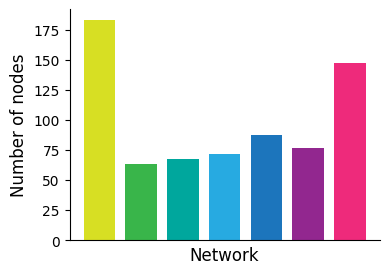

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes, x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

fig.savefig(os.path.join('htfa_node_counts.pdf'), bbox_inches='tight')

In [ ]:
locs_arch_1 = archs.A_[0]>.5

In [ ]:
arch_1_centers = centers[locs_arch_1]
arch_1_codes = node_codes['code'][locs_arch_1]
arch_1_nets = node_codes['Network'][locs_arch_1]

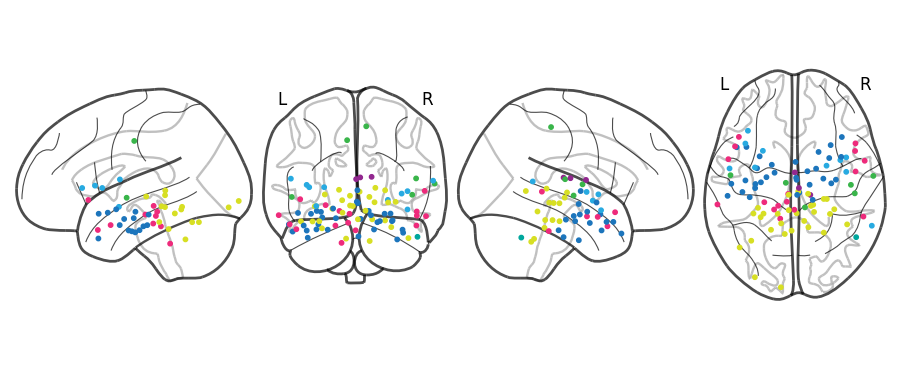

In [ ]:
nl.plotting.plot_connectome(np.eye(arch_1_centers.shape[0]), arch_1_centers, node_size=10, node_color=[colors[i] for i in arch_1_codes], display_mode='lyrz')

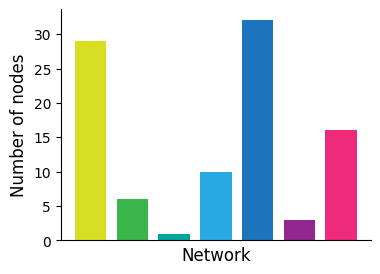

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_1], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

In [ ]:
locs_arch_2 = archs.A_[1]>.5

In [ ]:
arch_2_centers = centers[locs_arch_2]
arch_2_codes = node_codes['code'][locs_arch_2]
arch_2_nets = node_codes['Network'][locs_arch_2]

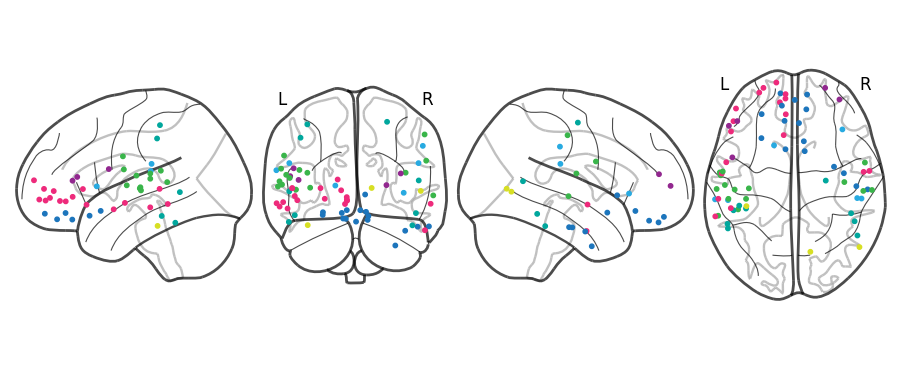

In [ ]:
nl.plotting.plot_connectome(np.eye(arch_2_centers.shape[0]), arch_2_centers, node_size=10, node_color=[colors[i] for i in arch_2_codes], display_mode='lyrz')

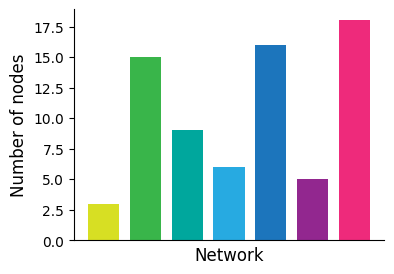

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_2], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

In [ ]:
locs_arch_3 = archs.A_[2]>.5
arch_3_centers = centers[locs_arch_3]
arch_3_codes = node_codes['code'][locs_arch_3]
arch_3_nets = node_codes['Network'][locs_arch_3]

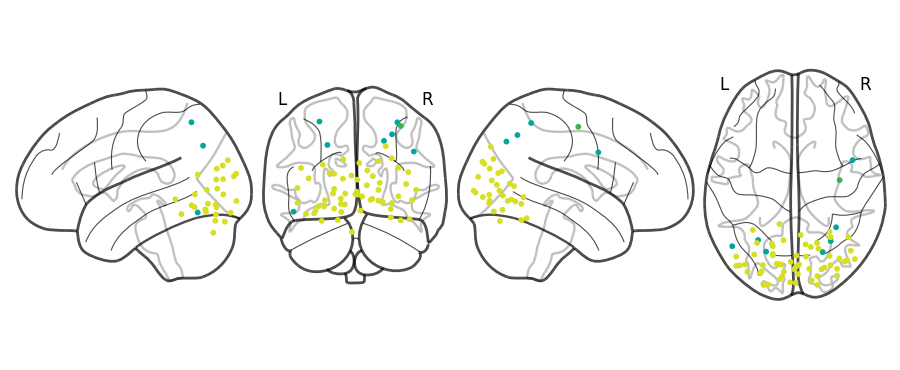

In [ ]:
nl.plotting.plot_connectome(np.eye(arch_3_centers.shape[0]), arch_3_centers, node_size=10, node_color=[colors[i] for i in arch_3_codes], display_mode='lyrz')

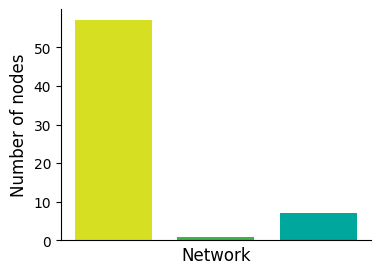

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_3], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

In [ ]:
locs_arch_4 = archs.A_[3]>.5
arch_4_centers = centers[locs_arch_4]
arch_4_codes = node_codes['code'][locs_arch_4]
arch_4_nets = node_codes['Network'][locs_arch_4]

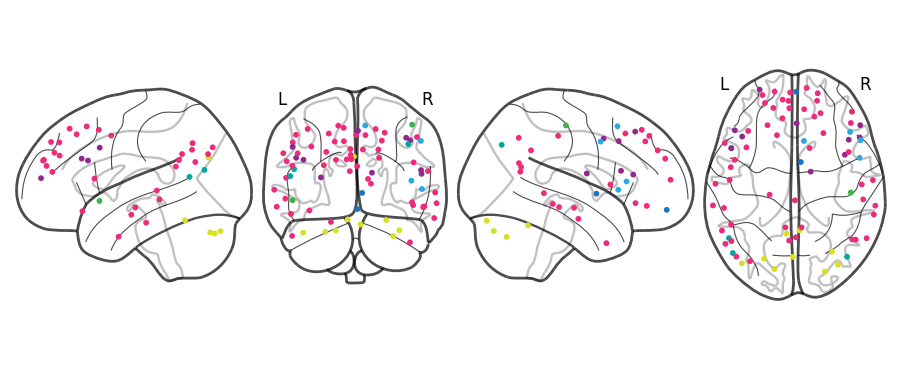

In [ ]:
nl.plotting.plot_connectome(np.eye(arch_4_centers.shape[0]), arch_4_centers, node_size=10, node_color=[colors[i] for i in arch_4_codes], display_mode='lyrz')

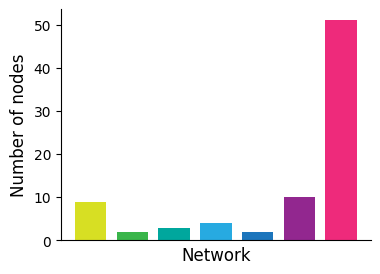

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_4], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

In [ ]:
locs_arch_5 = archs.A_[4]>.5
arch_5_centers = centers[locs_arch_5]
arch_5_codes = node_codes['code'][locs_arch_5]
arch_5_nets = node_codes['Network'][locs_arch_5]

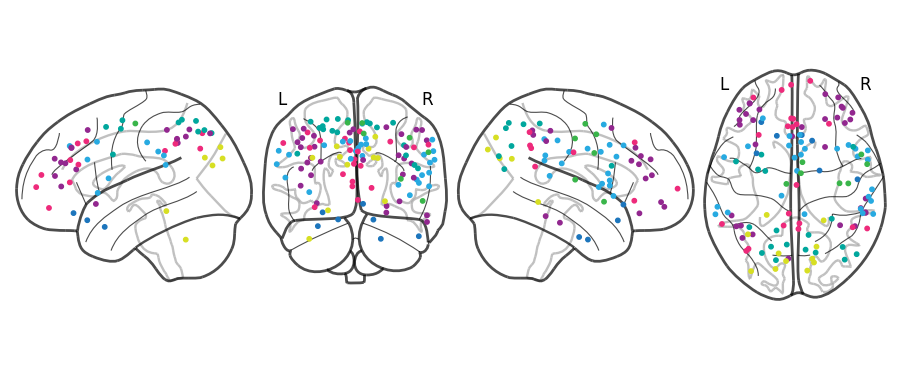

In [ ]:
nl.plotting.plot_connectome(np.eye(arch_5_centers.shape[0]), arch_5_centers, node_size=10, node_color=[colors[i] for i in arch_5_codes], display_mode='lyrz')

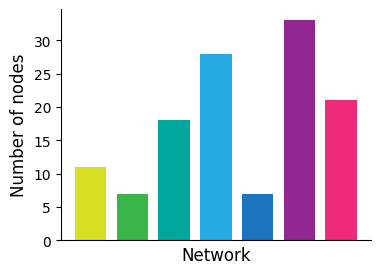

In [ ]:
fig = plt.figure(figsize=(4, 3))
ax = plt.gca()

sns.histplot(data=node_codes[locs_arch_5], x='code', color='k', shrink=0.75, hue='code', hue_order=range(1, 8), palette=colors[1:], alpha=1.0, legend=False, ax=ax, discrete=True, edgecolor=None)
ax.set_xlabel('Network', fontsize=12)
ax.set_ylabel('Number of nodes', fontsize=12)

ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)